# Day 2: Linear Layers, Activations & Building Your First Model
## Defense Prep - Coding Exercises (Offline Model Track)

**Focus**: Understanding what happens INSIDE a neural network — the building blocks of your BaseCompressor.

**Structure**:
- Exercise 1 (Easy): ReLU activation from scratch
- Exercise 2 (Easy): Linear layer — weights, biases, shapes
- Exercise 3 (Medium): Build BaseCompressor as `nn.Module`
- Exercise 4 (Hard): Complete training loop on synthetic data
- 5 Theory questions

**Time**: ~1.5 hrs coding, ~30 min theory

---

In [1]:
import torch
import torch.nn as nn
import numpy as np
print('PyTorch:', torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

PyTorch: 2.2.2
Device: cpu


---

## Exercise 1 (Easy): ReLU Activation From Scratch

**What is an activation function?**

A linear layer computes $y = xW^T + b$. No matter how many linear layers you stack, the result is still a linear transformation. **Activation functions add non-linearity**, allowing the network to learn complex patterns.

Your thesis models use **ReLU** (Rectified Linear Unit) between all hidden layers.

### Task 1a: Implement ReLU without using `torch.relu` or `nn.ReLU`

$$\text{ReLU}(x) = \max(0, x) = \begin{cases} x & \text{if } x > 0 \\ 0 & \text{if } x \leq 0 \end{cases}$$

In [16]:
def my_relu(x):
    """
    Implement ReLU activation without using torch.relu or nn.ReLU.
    Args:
        x: Input tensor of any shape
    Returns:
        Tensor with ReLU applied element-wise
    """
    # YOUR CODE HERE
    return torch.clamp(x, min=0)

In [17]:
# === TEST 1a ===
test_1d = torch.tensor([-3.0, -1.0, 0.0, 1.0, 3.0])
expected_1d = torch.tensor([0.0, 0.0, 0.0, 1.0, 3.0])
result_1d = my_relu(test_1d)
assert torch.equal(result_1d, expected_1d), 'ReLU 1D failed: got {}'.format(result_1d)

test_2d = torch.tensor([[-2.0, 5.0], [0.3, -0.7]])
expected_2d = torch.tensor([[0.0, 5.0], [0.3, 0.0]])
assert torch.equal(my_relu(test_2d), expected_2d), 'ReLU 2D failed'

# Must match PyTorch's own ReLU
torch.manual_seed(42)
big_test = torch.randn(200, 50)
assert torch.equal(my_relu(big_test), torch.relu(big_test)), 'Must match torch.relu on random data'

print('Test 1a passed!')

Test 1a passed!


### Task 1b: Visualize ReLU

Plot ReLU for $x \in [-5, 5]$. This helps you see what it does: passes positive values unchanged, kills negative values.

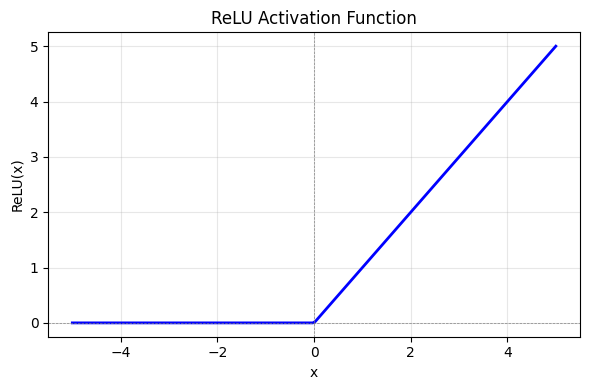

In [18]:
import matplotlib.pyplot as plt

x_vals = torch.linspace(-5, 5, 200)

# YOUR CODE HERE: apply my_relu to x_vals
y_vals = my_relu(x_vals)

plt.figure(figsize=(6, 4))
plt.plot(x_vals.numpy(), y_vals.numpy(), color='blue', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
plt.xlabel('x')
plt.ylabel('ReLU(x)')
plt.title('ReLU Activation Function')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# === TEST 1b ===
assert y_vals is not None and not isinstance(y_vals, type(Ellipsis)), 'y_vals not computed'
assert y_vals.shape == (200,), 'y_vals shape wrong: {}'.format(y_vals.shape)
assert y_vals.min() == 0.0, 'ReLU min should be 0'
assert y_vals.max() == 5.0, 'ReLU max should be 5 for input range [-5, 5]'

print('Test 1b passed!')

Test 1b passed!


---

## Exercise 2 (Easy): Linear Layer — Weights, Biases & Shapes

A linear (fully-connected) layer computes:

$$\mathbf{y} = \mathbf{x} \mathbf{W}^T + \mathbf{b}$$

where:
- $\mathbf{x}$: input tensor, shape $(\text{batch}, \text{in\_features})$
- $\mathbf{W}$: weight matrix, shape $(\text{out\_features}, \text{in\_features})$
- $\mathbf{b}$: bias vector, shape $(\text{out\_features},)$
- $\mathbf{y}$: output tensor, shape $(\text{batch}, \text{out\_features})$

### Task 2a: Explore `nn.Linear`

Create the **first layer** of your BaseCompressor: `nn.Linear(4, 64)` (4 inputs → 64 outputs).

Then fill in the values below by inspecting the layer's attributes.

In [20]:
torch.manual_seed(42)

# Create the layer
layer = nn.Linear(4, 64)

# YOUR CODE HERE: inspect the layer and fill in these values
weight_shape = nn.Linear(64,64)   # shape of layer.weight (as a tuple)
bias_shape = nn.Linear(64,)        # shape of layer.bias (as a tuple)
num_weight_params = len(weight_shape) # total number of values in weight matrix (int)
num_bias_params = len(bias_shape)   # total number of values in bias vector (int)
total_params =  num_weight_params + num_bias_params   # total learnable parameters in this layer (int)

TypeError: Linear.__init__() missing 1 required positional argument: 'out_features'

In [ ]:
# === TEST 2a ===
assert weight_shape == (64, 4), 'Weight shape is (out, in) = (64, 4), got {}'.format(weight_shape)
assert bias_shape == (64,), 'Bias shape is (out,) = (64,), got {}'.format(bias_shape)
assert num_weight_params == 256, 'Weights: 64 * 4 = 256, got {}'.format(num_weight_params)
assert num_bias_params == 64, 'Biases: 64, got {}'.format(num_bias_params)
assert total_params == 320, 'Total: 256 + 64 = 320, got {}'.format(total_params)

print('Test 2a passed!')
print('Layer: Linear(4 -> 64)')
print('  Weight: {} = {} params'.format(weight_shape, num_weight_params))
print('  Bias:   {} = {} params'.format(bias_shape, num_bias_params))
print('  Total:  {} params'.format(total_params))

### Task 2b: Manual Forward Pass

Compute the output of the linear layer **manually** using matrix multiplication, and verify it matches `layer(x)`.

Given input `x` of shape $(8, 4)$ (batch of 8, each with 4 features):

$$\mathbf{y}_{\text{manual}} = \mathbf{x} \cdot \mathbf{W}^T + \mathbf{b}$$

Use `@` for matrix multiply and `.T` for transpose.

In [ ]:
torch.manual_seed(0)
x = torch.randn(8, 4)  # batch of 8, 4 input features

# YOUR CODE HERE
# Step 1: Compute output using PyTorch's layer
y_pytorch = ...             # just call layer(x)

# Step 2: Compute output MANUALLY: y = x @ W^T + b
W = layer.weight            # shape (64, 4)
b = layer.bias              # shape (64,)
y_manual = ...              # use @ and .T

In [ ]:
# === TEST 2b ===
assert y_pytorch.shape == (8, 64), 'PyTorch output shape wrong: {}'.format(y_pytorch.shape)
assert y_manual.shape == (8, 64), 'Manual output shape wrong: {}'.format(y_manual.shape)
assert torch.allclose(y_pytorch, y_manual, atol=1e-6), 'Manual and PyTorch outputs must match!'

print('Test 2b passed!')
print('Input shape:  {}'.format(x.shape))
print('Output shape: {}'.format(y_manual.shape))
print('Verified: x @ W.T + b == layer(x)')

### Task 2c: Parameter Count Formula

Write a function that calculates the number of parameters in an `nn.Linear(in_f, out_f)` layer.

$$\text{params} = \underbrace{\text{in\_features} \times \text{out\_features}}_{\text{weights}} + \underbrace{\text{out\_features}}_{\text{biases}}$$

In [ ]:
def count_linear_params(in_features, out_features):
    """
    Calculate number of learnable parameters in nn.Linear(in_features, out_features).
    Returns: int
    """
    # YOUR CODE HERE
    pass

In [ ]:
# === TEST 2c ===
assert count_linear_params(4, 64) == 320, 'Linear(4,64): 4*64+64 = 320'
assert count_linear_params(64, 64) == 4160, 'Linear(64,64): 64*64+64 = 4160'
assert count_linear_params(64, 32) == 2080, 'Linear(64,32): 64*32+32 = 2080'
assert count_linear_params(32, 4) == 132, 'Linear(32,4): 32*4+4 = 132'

# Now calculate total for BaseCompressor: 4 -> 64 -> 64 -> 32 -> 4
base_total = (count_linear_params(4, 64) + count_linear_params(64, 64) +
              count_linear_params(64, 32) + count_linear_params(32, 4))
assert base_total == 6692, 'BaseCompressor should have 6692 params, got {}'.format(base_total)

print('Test 2c passed!')
print('\nBaseCompressor parameter breakdown:')
print('  Linear(4, 64):  {}'.format(count_linear_params(4, 64)))
print('  Linear(64, 64): {}'.format(count_linear_params(64, 64)))
print('  Linear(64, 32): {}'.format(count_linear_params(64, 32)))
print('  Linear(32, 4):  {}'.format(count_linear_params(32, 4)))
print('  Total:          {}'.format(base_total))

---

## Exercise 3 (Medium): Build BaseCompressor as `nn.Module`

Now combine everything: build the full BaseCompressor model.

**Architecture:**

$$\text{Input}(4) \xrightarrow{\text{Linear}} 64 \xrightarrow{\text{ReLU}} 64 \xrightarrow{\text{ReLU}} 32 \xrightarrow{\text{ReLU}} \text{Output}(4)$$

### Task 3a: Define the model

Create a class `BaseCompressor(nn.Module)` with:
- `__init__`: define 4 linear layers and use `nn.Sequential` to chain them with `nn.ReLU()` between hidden layers
- `forward(self, x)`: pass input through the network

**Important**: NO activation on the output layer!

In [ ]:
class BaseCompressor(nn.Module):
    def __init__(self):
        super().__init__()
        # YOUR CODE HERE
        # Define self.network using nn.Sequential with:
        #   Linear(4, 64) -> ReLU -> Linear(64, 64) -> ReLU -> Linear(64, 32) -> ReLU -> Linear(32, 4)
        pass

    def forward(self, x):
        # YOUR CODE HERE
        pass

In [ ]:
# === TEST 3a ===
torch.manual_seed(42)
model = BaseCompressor()

# Check parameter count
total_params = sum(p.numel() for p in model.parameters())
assert total_params == 6692, 'Should have 6692 params, got {}'.format(total_params)

# Check forward pass shape
test_input = torch.randn(16, 4)
test_output = model(test_input)
assert test_output.shape == (16, 4), 'Output shape should be (16, 4), got {}'.format(test_output.shape)

# Check no ReLU on output (output should contain negative values with random weights)
torch.manual_seed(0)
model_check = BaseCompressor()
big_output = model_check(torch.randn(1000, 4))
assert (big_output < 0).any().item(), 'Output must have negatives (no ReLU on output layer!)'

print('Test 3a passed!')
print('Total parameters: {:,}'.format(total_params))
print('Model size: {:.1f} KB (float32)'.format(total_params * 4 / 1024))

### Task 3b: Build MediumCompressor and LargeCompressor

Same pattern, different sizes:

| Model | Architecture | Expected Params |
|:-----:|:------------:|:---------------:|
| MediumCompressor | $4 \to 96 \to 96 \to 48 \to 4$ | 14,644 |
| LargeCompressor | $4 \to 128 \to 128 \to 64 \to 4$ | 25,668 |

In [ ]:
class MediumCompressor(nn.Module):
    def __init__(self):
        super().__init__()
        # YOUR CODE HERE
        pass

    def forward(self, x):
        # YOUR CODE HERE
        pass


class LargeCompressor(nn.Module):
    def __init__(self):
        super().__init__()
        # YOUR CODE HERE
        pass

    def forward(self, x):
        # YOUR CODE HERE
        pass

In [ ]:
# === TEST 3b ===
med = MediumCompressor()
large = LargeCompressor()

med_params = sum(p.numel() for p in med.parameters())
large_params = sum(p.numel() for p in large.parameters())

assert med_params == 14644, 'MediumCompressor: expected 14644, got {}'.format(med_params)
assert large_params == 25668, 'LargeCompressor: expected 25668, got {}'.format(large_params)

# Check forward pass
x_test = torch.randn(10, 4)
assert med(x_test).shape == (10, 4), 'Medium output shape wrong'
assert large(x_test).shape == (10, 4), 'Large output shape wrong'

print('Test 3b passed!')
print('\nModel Comparison:')
print('  Base:   {:>6,} params  ({:>5.1f} KB)'.format(6692, 6692 * 4 / 1024))
print('  Medium: {:>6,} params  ({:>5.1f} KB)'.format(med_params, med_params * 4 / 1024))
print('  Large:  {:>6,} params  ({:>5.1f} KB)'.format(large_params, large_params * 4 / 1024))

---

## Exercise 4 (Hard): Complete Training Loop

Put everything together: load data, create model, train it, and check that the loss decreases.

We will use a **small synthetic dataset** (same structure as your real data) so training finishes in seconds.

### Task 4a: Prepare the data

Using the `MiniSpatioTemporalDataset` from Day 1, create a dataset and DataLoader.

You must **re-define** the Dataset class here (or copy from Day 1) since this is a new notebook.

In [ ]:
from torch.utils.data import Dataset, DataLoader

class MiniSpatioTemporalDataset(Dataset):
    def __init__(self, data_array):
        inputs_np = data_array[:, :4]
        targets_np = data_array[:, 4:]

        self.input_min = inputs_np.min(axis=0)
        self.input_max = inputs_np.max(axis=0)
        self.input_range = self.input_max - self.input_min
        self.input_range[self.input_range == 0] = 1.0
        inputs_normed = (inputs_np - self.input_min) / self.input_range

        self.target_min = targets_np.min(axis=0)
        self.target_max = targets_np.max(axis=0)
        self.target_range = self.target_max - self.target_min
        self.target_range[self.target_range == 0] = 1.0
        targets_normed = (targets_np - self.target_min) / self.target_range

        self.inputs = torch.tensor(inputs_normed, dtype=torch.float32)
        self.targets = torch.tensor(targets_normed, dtype=torch.float32)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

    def denormalize_targets(self, normalized):
        if isinstance(normalized, torch.Tensor):
            normalized = normalized.numpy()
        return normalized * self.target_range + self.target_min

In [ ]:
# Create synthetic data (same structure as Day 1)
np.random.seed(42)
N = 2000
x = np.random.rand(N) * 3.0 - 0.5
y = np.random.rand(N) * 1.0 - 0.5
z = np.zeros(N)
t = np.repeat(np.linspace(0, 0.396, 20), N // 20)
Vx = np.sin(x * 2) * np.cos(t * 10) + np.random.randn(N) * 0.05
Vy = np.cos(y * 3) * np.sin(t * 5) + np.random.randn(N) * 0.05
P = 100000 + 1000 * np.sin(x + y) * np.cos(t * 8) + np.random.randn(N) * 10
TKE = 10 + 5 * np.abs(np.sin(x * y * t * 50)) + np.random.randn(N) * 0.1

synthetic_data = np.column_stack([x, y, z, t, Vx, Vy, P, TKE])
print('Synthetic data shape:', synthetic_data.shape)

In [ ]:
# YOUR CODE HERE
# Step 1: Create the dataset
dataset = ...

# Step 2: Create a DataLoader with batch_size=128, shuffle=True
BATCH_SIZE = 128
train_loader = ...

In [ ]:
# === TEST 4a ===
assert len(dataset) == 2000, 'Dataset should have 2000 samples'
inp, tgt = dataset[0]
assert inp.shape == (4,) and tgt.shape == (4,), 'Sample shapes wrong'

batch_inp, batch_tgt = next(iter(train_loader))
assert batch_inp.shape == (128, 4), 'Batch input shape wrong: {}'.format(batch_inp.shape)

print('Test 4a passed!')
print('Dataset: {} samples, Batch size: {}'.format(len(dataset), BATCH_SIZE))

### Task 4b: Write the Training Loop

Train the `BaseCompressor` for **50 epochs**. Fill in the 5 steps of the training loop:

1. **Forward pass**: feed batch through model
2. **Compute loss**: MSE between predictions and targets
3. **Zero gradients**: clear old gradients from previous step
4. **Backward pass**: compute new gradients
5. **Update weights**: optimizer takes a step

Track the average loss per epoch in a list.

In [ ]:
torch.manual_seed(42)

# Create model, loss function, optimizer
model = BaseCompressor().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

NUM_EPOCHS = 50
epoch_losses = []

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    num_batches = 0

    for batch_inputs, batch_targets in train_loader:
        # Move data to device
        batch_inputs = batch_inputs.to(device)
        batch_targets = batch_targets.to(device)

        # YOUR CODE HERE: fill in the 5 training steps

        # Step 1: Forward pass
        predictions = ...

        # Step 2: Compute loss
        loss = ...

        # Step 3: Zero gradients
        # ...

        # Step 4: Backward pass
        # ...

        # Step 5: Update weights
        # ...

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    epoch_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print('Epoch {}/{}, Loss: {:.6f}'.format(epoch + 1, NUM_EPOCHS, avg_loss))

In [ ]:
# === TEST 4b ===
assert len(epoch_losses) == 50, 'Should have 50 epoch losses, got {}'.format(len(epoch_losses))
assert epoch_losses[-1] < epoch_losses[0], 'Loss should decrease! First: {:.4f}, Last: {:.4f}'.format(
    epoch_losses[0], epoch_losses[-1])
assert epoch_losses[-1] < 0.1, 'Final loss should be < 0.1, got {:.4f}'.format(epoch_losses[-1])

# Verify model learned something
model.eval()
with torch.no_grad():
    sample_inp, sample_tgt = dataset[:20]
    sample_pred = model(sample_inp.to(device)).cpu()
    error = (sample_pred - sample_tgt).abs().mean().item()
    assert error < 0.2, 'Mean absolute error should be < 0.2, got {:.4f}'.format(error)

print('Test 4b passed!')
print('Loss: {:.4f} -> {:.6f}'.format(epoch_losses[0], epoch_losses[-1]))

### Task 4c: Plot the Training Loss Curve

Plot the loss curve. This is the same type of plot your thesis generates for each model.

In [ ]:
# YOUR CODE HERE
# Plot epoch_losses using matplotlib
# X-axis: epoch number (1 to 50)
# Y-axis: MSE loss
# Add title, labels, and grid


---

## Part E: Theory Questions

Write your answers in the cells below. We will discuss these together.

---

### Q1: Why ReLU instead of Sigmoid?

Sigmoid: $\sigma(x) = \frac{1}{1 + e^{-x}}$ squashes output to $(0, 1)$.

ReLU: $\text{ReLU}(x) = \max(0, x)$ output is $[0, \infty)$.

Why does your thesis use ReLU? What problem does Sigmoid have during training of deep networks? *(Hint: think about gradients)*

**YOUR ANSWER:**

...

### Q2: Why is there NO activation function on the output layer?

Your models apply ReLU after every hidden layer but NOT after the final `Linear(32, 4)`. Why?

**YOUR ANSWER:**

...

### Q3: What does the bias term $b$ actually do?

In $y = xW^T + b$, what role does $b$ play? What would happen if you set `bias=False` in all your `nn.Linear` layers?

**YOUR ANSWER:**

...

### Q4: What is the Universal Approximation Theorem?

This theorem is the theoretical foundation for why your approach works. In simple terms:

- What does it say?
- How does it justify using a neural network to represent a continuous field $f(x, y, z, t)$?
- Does it guarantee a small network will work? Why or why not?

**YOUR ANSWER:**

...

### Q5: Why does a larger model not always give better results?

Your results show:

| Model | Params | Offline PSNR | Online Full-Dataset PSNR |
|:-----:|:------:|:------------:|:------------------------:|
| Base | 6,692 | 32.15 dB | 11.97 dB |
| Medium | 14,644 | 33.58 dB | 12.70 dB |
| Large | 25,668 | 35.99 dB | 9.67 dB |

In offline mode, larger is better. But in online mode, the Large model has the **worst** full-dataset PSNR. Why?

**YOUR ANSWER:**

...

---

## Summary: What You Built Today

| Exercise | Concept | Thesis Connection |
|:--------:|:-------:|:-----------------:|
| 1 (Easy) | ReLU activation from scratch | Activation in all 3 models |
| 2 (Easy) | Linear layer, manual forward pass, param counting | Core of `nn.Linear`, model size |
| 3 (Medium) | Build Base/Medium/LargeCompressor | Exact thesis architectures |
| 4 (Hard) | Training loop with DataLoader | Core of all training scripts |
| Q1–Q5 | Theory: activations, UAT, overfitting | Defense questions |

**Tomorrow (Day 3)**: Loss functions (MSE), evaluation metrics (PSNR, SSIM, Relative L2 Error), and model saving/loading.

---